# Exploratory Data Analysis - Charité Dataset

**Objective:** Analyze the Charité-Universitätsmedizin Berlin dataset to understand FoG patterns and data characteristics.

**Dataset:** 16 Parkinson's patients, 2 sensors (left/right foot), 200 Hz sampling rate

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loaders import ChariteDatasetLoader

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Dataset

In [2]:
# Load data (only walking trials, left foot for initial analysis)
loader = ChariteDatasetLoader('../../Datasets/Charité–Universitätsmedizin Berlin/Data Sheet 2/data')
df = loader.load_all_data(verbose=True, foot='left')

# Add subject and trial string identifiers
df['subject'] = df['subject_id'].apply(lambda x: f'S{x:02d}')
df['trial'] = df['trial_id'].apply(lambda x: f'T{x}')

print(f"\nDataset shape: {df.shape}")
print(f"Subjects: {df['subject'].nunique()}")
print(f"Foot: {df['foot'].unique()}")
print(f"Total duration: {df['time_s'].max():.1f} seconds ({df['time_s'].max()/60:.1f} minutes)")

📁 Encontrados 32 archivos CSV
🦶 Filtrando por pie: left
📊 Cargando datos del dataset Charité-Universitätsmedizin...



Cargando archivos: 100%|██████████| 32/32 [00:00<00:00, 58.46it/s]



✅ Dataset cargado exitosamente

RESUMEN DEL DATASET: ChariteDatasetLoader

📊 Información General:
   Dimensiones: (428195, 13)
   Filas: 428,195
   Columnas: 13
   Memoria: 107.82 MB

👥 Sujetos: 16
📁 Archivos: 32

🚨 Episodios de FoG:
   Muestras con FoG: 288,190 (67.30%)
   Muestras sin FoG: 140,005 (32.70%)


Dataset shape: (428195, 15)
Subjects: 16
Foot: <StringArray>
['left']
Length: 1, dtype: str
Total duration: 362.3 seconds (6.0 minutes)


## 2. Data Structure

In [3]:
# Display first rows
df.head()

,time_s,acc_x_m_s2,acc_y_m_s2,acc_z_m_s2,gyr_x_deg_s,gyr_y_deg_s,gyr_z_deg_s,fog_label,subject_id,trial_id,foot,filename,fog_label_text,subject,trial
0,0.000,0.900558,4.275198,9.152730,0.7,-0.1,0.3,0,1,1,left,S1_left_foot_trial_1.csv,No FoG,S01,T1
1,0.005,0.937836,4.275198,9.115453,0.9,-0.1,0.5,0,1,1,left,S1_left_foot_trial_1.csv,No FoG,S01,T1
2,0.010,0.937836,4.275198,9.115453,0.7,0.0,0.9,0,1,1,left,S1_left_foot_trial_1.csv,No FoG,S01,T1
3,0.015,0.900558,4.349754,9.080136,0.7,-0.2,0.5,0,1,1,left,S1_left_foot_trial_1.csv,No FoG,S01,T1
4,0.020,0.900558,4.385070,9.152730,0.6,0.0,0.2,0,1,1,left,S1_left_foot_trial_1.csv,No FoG,S01,T1


In [4]:
# Data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 428195 entries, 0 to 428194
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   time_s          428195 non-null  float64
 1   acc_x_m_s2      428195 non-null  float64
 2   acc_y_m_s2      428195 non-null  float64
 3   acc_z_m_s2      428195 non-null  float64
 4   gyr_x_deg_s     428195 non-null  float64
 5   gyr_y_deg_s     428195 non-null  float64
 6   gyr_z_deg_s     428195 non-null  float64
 7   fog_label       428195 non-null  int64  
 8   subject_id      428195 non-null  int64  
 9   trial_id        428195 non-null  int64  
 10  foot            428195 non-null  str    
 11  filename        428195 non-null  str    
 12  fog_label_text  428195 non-null  str    
 13  subject         428195 non-null  str    
 14  trial           428195 non-null  str    
dtypes: float64(7), int64(3), str(5)
memory usage: 49.0 MB


In [5]:
# Statistical summary
df.describe()

,time_s,acc_x_m_s2,acc_y_m_s2,acc_z_m_s2,gyr_x_deg_s,gyr_y_deg_s,gyr_z_deg_s,fog_label,subject_id,trial_id
count,428195.000000,428195.000000,428195.000000,428195.000000,428195.000000,428195.000000,428195.000000,428195.000000,428195.000000,428195.000000
mean,67.980075,-1.786682,5.699316,8.218611,0.130135,-1.059658,0.051023,0.673034,6.929952,1.515524
std,78.655224,3.045949,3.788780,3.127068,68.617867,38.861922,56.446626,0.469105,4.707484,0.499760
min,0.000000,-84.437940,-68.526120,-77.178540,-1253.900000,-597.900000,-802.200000,0.000000,1.000000,1.000000
25%,16.725000,-2.360940,4.754580,7.965523,-3.000000,-1.700000,-1.600000,0.000000,3.000000,1.000000
50%,35.655000,-1.759260,5.085504,8.567400,0.400000,0.000000,0.000000,1.000000,6.000000,2.000000
75%,87.422500,-1.238022,5.781360,8.783220,4.600000,1.800000,2.100000,1.000000,11.000000,2.000000
max,362.290000,57.028800,56.735160,54.555370,1166.800000,434.200000,698.200000,1.000000,16.000000,2.000000


## 3. FoG Distribution Analysis

Labels: 0 = No FoG, 1 = FoG

In [6]:
# Overall FoG distribution
fog_counts = df['fog_label'].value_counts().sort_index()
fog_pct = (fog_counts / len(df) * 100).round(2)

print("FoG Distribution:")
print(f"  No FoG (0): {fog_counts[0]:,} samples ({fog_pct[0]}%)")
print(f"  FoG (1):    {fog_counts[1]:,} samples ({fog_pct[1]}%)")
print(f"\nClass imbalance ratio: {fog_counts[0]/fog_counts[1]:.1f}:1")

FoG Distribution:
  No FoG (0): 140,005 samples (32.7%)
  FoG (1):    288,190 samples (67.3%)

Class imbalance ratio: 0.5:1


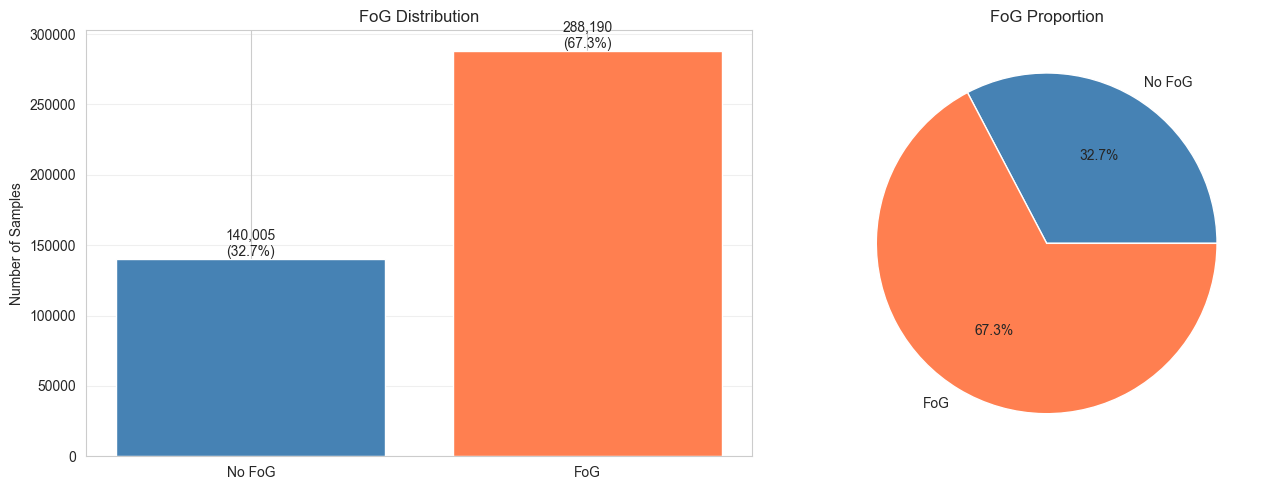

In [7]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1.bar(['No FoG', 'FoG'], fog_counts.values, color=['steelblue', 'coral'])
ax1.set_ylabel('Number of Samples')
ax1.set_title('FoG Distribution')
ax1.grid(axis='y', alpha=0.3)
for i, (count, pct) in enumerate(zip(fog_counts.values, fog_pct.values)):
    ax1.text(i, count, f'{count:,}\n({pct}%)', ha='center', va='bottom')

# Pie chart
ax2.pie(fog_counts.values, labels=['No FoG', 'FoG'], autopct='%1.1f%%',
        colors=['steelblue', 'coral'])
ax2.set_title('FoG Proportion')

plt.tight_layout()
plt.show()

## 4. Subject-Level Analysis

In [8]:
# Samples per subject
subject_summary = df.groupby('subject').agg({
    'time_s': 'count',
    'fog_label': lambda x: (x == 1).sum()
}).rename(columns={'time_s': 'total_samples', 'fog_label': 'fog_samples'})

subject_summary['fog_percentage'] = (subject_summary['fog_samples'] / 
                                      subject_summary['total_samples'] * 100).round(2)

print("Subject Statistics:")
print(subject_summary)

Subject Statistics:
         total_samples  fog_samples  fog_percentage
subject                                            
S01              13189         4099           31.08
S02              58969        51867           87.96
S03             117559       107841           91.73
S04              10008         2676           26.74
S05              13744         3921           28.53
S06              18768         9481           50.52
S07              12961         4406           33.99
S08              24957        13210           52.93
S09              14938         7888           52.80
S10              21057         9277           44.06
S11              22514        16147           71.72
S12              24116        14462           59.97
S13              17305        10302           59.53
S14              17165         8821           51.39
S15              30629        21064           68.77
S16              10316         2728           26.44


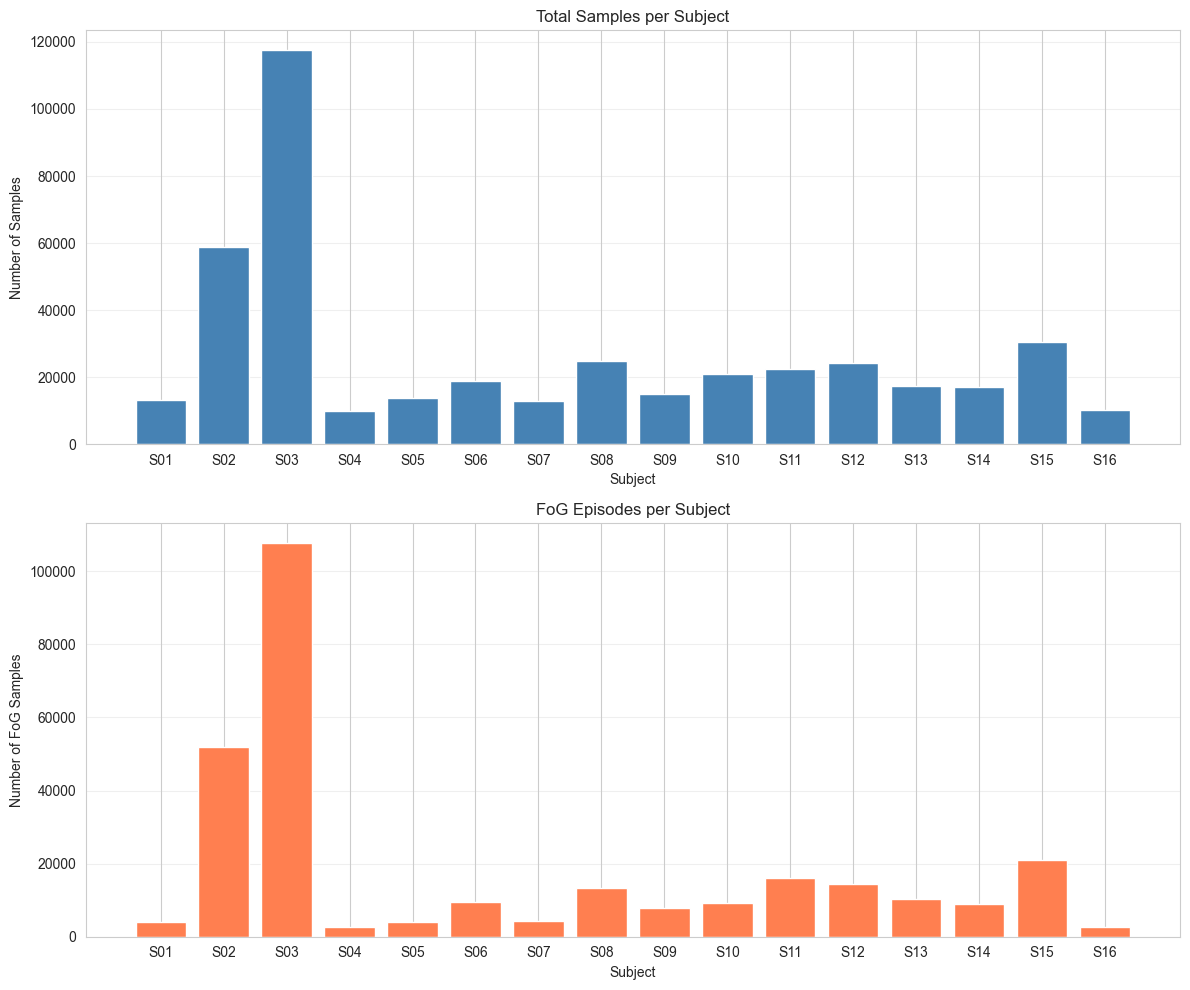

In [9]:
# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Total samples per subject
ax1.bar(subject_summary.index, subject_summary['total_samples'], color='steelblue')
ax1.set_xlabel('Subject')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Total Samples per Subject')
ax1.grid(axis='y', alpha=0.3)

# FoG samples per subject
ax2.bar(subject_summary.index, subject_summary['fog_samples'], color='coral')
ax2.set_xlabel('Subject')
ax2.set_ylabel('Number of FoG Samples')
ax2.set_title('FoG Episodes per Subject')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Sensor Data Analysis

In [10]:
# Sensor columns: accelerometer + gyroscope
sensor_cols = ['acc_x_m_s2', 'acc_y_m_s2', 'acc_z_m_s2', 
               'gyr_x_deg_s', 'gyr_y_deg_s', 'gyr_z_deg_s']

print("Sensor measurements:")
for col in sensor_cols:
    print(f"  {col}")

Sensor measurements:
  acc_x_m_s2
  acc_y_m_s2
  acc_z_m_s2
  gyr_x_deg_s
  gyr_y_deg_s
  gyr_z_deg_s


In [11]:
# Compare sensor statistics for FoG vs No FoG
fog_data = df[df['fog_label'] == 1][sensor_cols]
no_fog_data = df[df['fog_label'] == 0][sensor_cols]

print("Sensor Statistics Comparison (Mean):")
print("\nNo FoG:")
print(no_fog_data.mean())
print("\nFoG:")
print(fog_data.mean())

Sensor Statistics Comparison (Mean):

No FoG:
acc_x_m_s2    -1.859450
acc_y_m_s2     6.289517
acc_z_m_s2     8.159877
gyr_x_deg_s    0.767780
gyr_y_deg_s   -1.555778
gyr_z_deg_s   -1.743826
dtype: float64

FoG:
acc_x_m_s2    -1.751331
acc_y_m_s2     5.412592
acc_z_m_s2     8.247144
gyr_x_deg_s   -0.179638
gyr_y_deg_s   -0.818638
gyr_z_deg_s    0.922975
dtype: float64


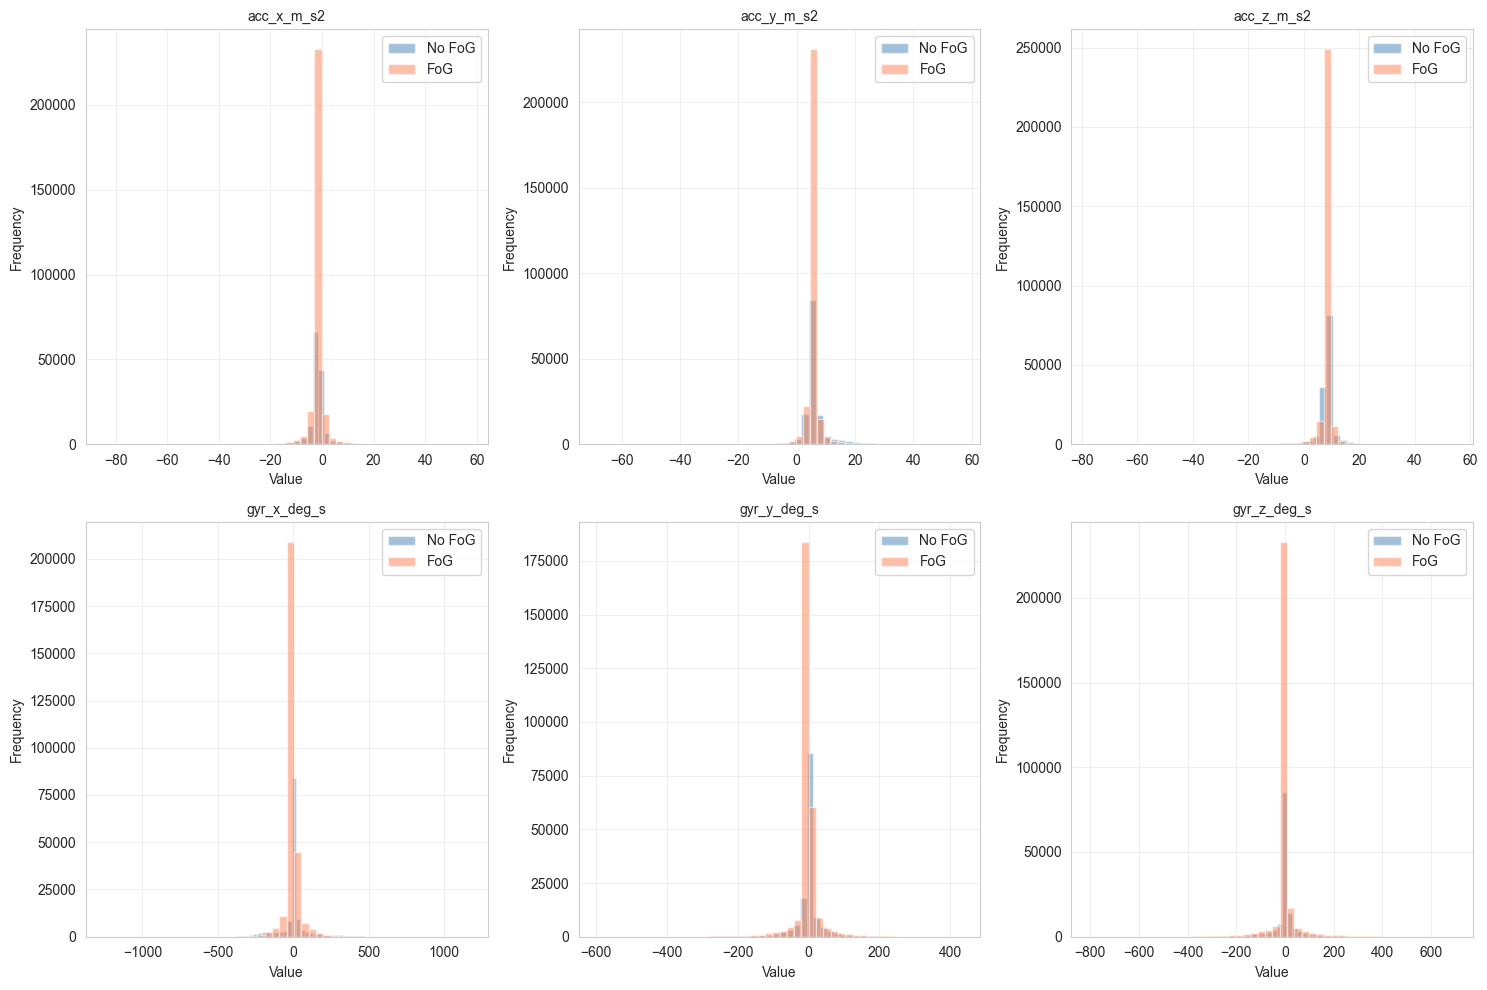

In [12]:
# Visualize sensor distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(sensor_cols):
    axes[i].hist(no_fog_data[col], bins=50, alpha=0.5, label='No FoG', color='steelblue')
    axes[i].hist(fog_data[col], bins=50, alpha=0.5, label='FoG', color='coral')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

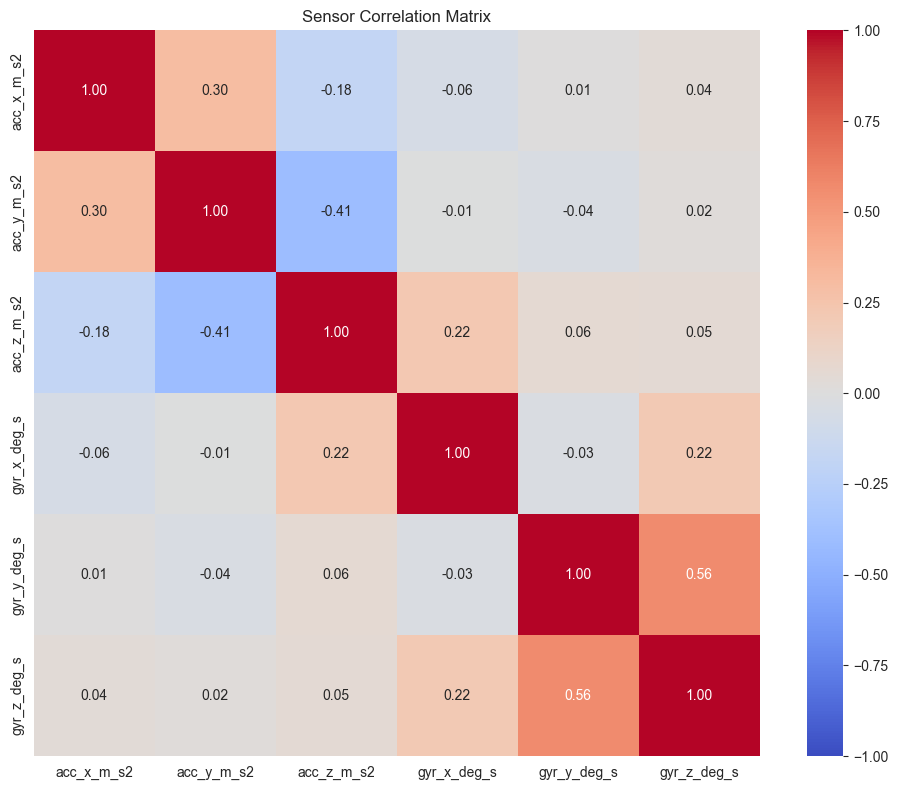

In [13]:
# Correlation matrix
corr_matrix = df[sensor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Sensor Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Temporal Patterns - Example FoG Episode

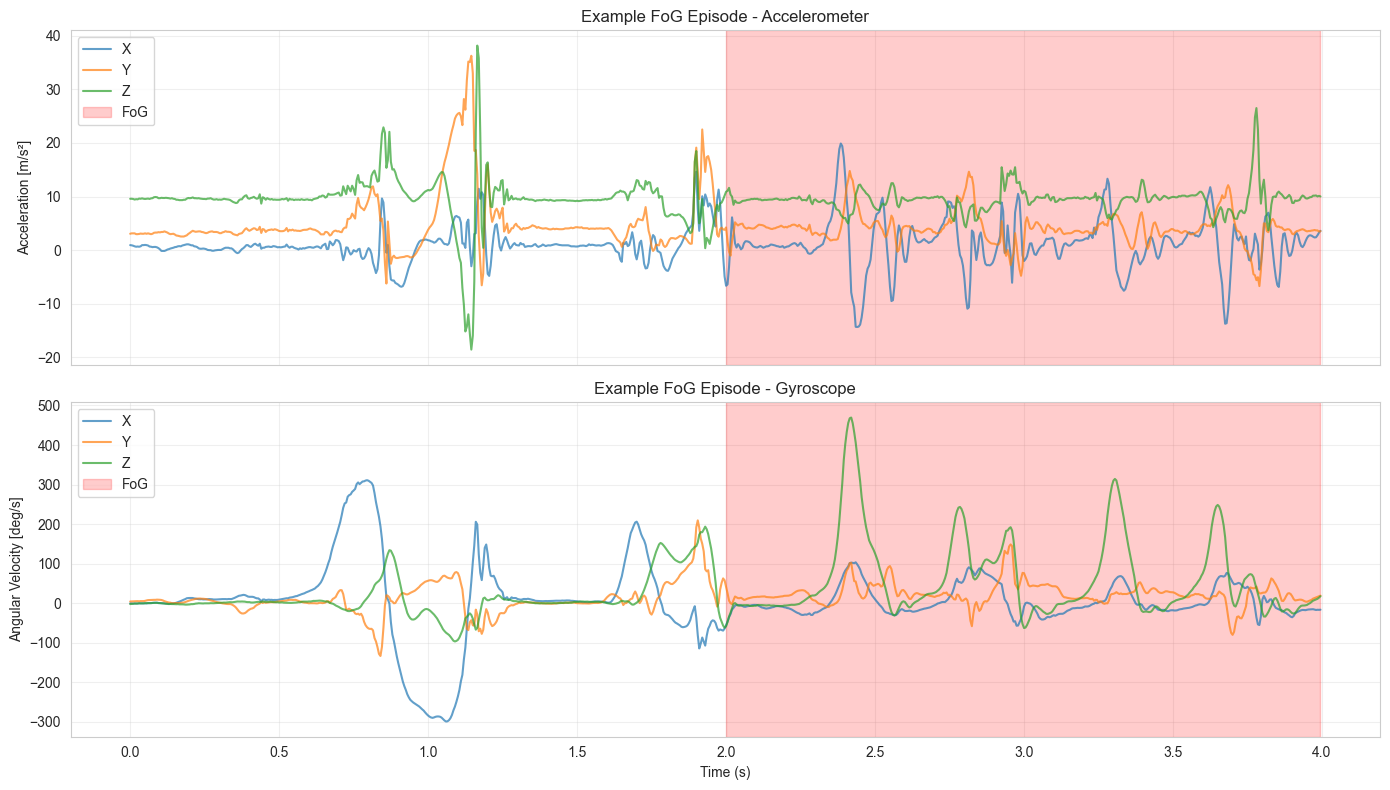

In [14]:
# Find a FoG episode and plot signals
subject = 'S01'
trial = 'T1'
mask = (df['subject'] == subject) & (df['trial'] == trial)
episode_data = df[mask].reset_index(drop=True)

# Find first FoG episode
fog_indices = episode_data[episode_data['fog_label'] == 1].index
if len(fog_indices) > 0:
    # Take 800 samples around FoG (4 seconds @ 200Hz)
    center = fog_indices[0]
    start = max(0, center - 400)
    end = min(len(episode_data), center + 400)
    window = episode_data.iloc[start:end]
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    time = window['time_s'].values - window['time_s'].values[0]
    
    # Accelerometer
    axes[0].plot(time, window['acc_x_m_s2'], label='X', alpha=0.7)
    axes[0].plot(time, window['acc_y_m_s2'], label='Y', alpha=0.7)
    axes[0].plot(time, window['acc_z_m_s2'], label='Z', alpha=0.7)
    axes[0].axvspan(time[window['fog_label']==1].min(), 
                     time[window['fog_label']==1].max(), 
                     alpha=0.2, color='red', label='FoG')
    axes[0].set_ylabel('Acceleration [m/s²]')
    axes[0].set_title('Example FoG Episode - Accelerometer')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Gyroscope
    axes[1].plot(time, window['gyr_x_deg_s'], label='X', alpha=0.7)
    axes[1].plot(time, window['gyr_y_deg_s'], label='Y', alpha=0.7)
    axes[1].plot(time, window['gyr_z_deg_s'], label='Z', alpha=0.7)
    axes[1].axvspan(time[window['fog_label']==1].min(), 
                     time[window['fog_label']==1].max(), 
                     alpha=0.2, color='red', label='FoG')
    axes[1].set_ylabel('Angular Velocity [deg/s]')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_title('Example FoG Episode - Gyroscope')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"No FoG episodes found in {subject} {trial}")

## Summary

**Key Findings:**
1. Class imbalance: FoG represents minority of samples
2. Subject variability: Different patients show different FoG patterns
3. Sensor characteristics: Accelerometer and gyroscope data show distinct patterns
4. FoG characteristics visible in both accelerometer and gyroscope signals

**Implications for ML:**
- Need to address class imbalance (ADASYN, class weights)
- Subject-independent validation critical (LOSO)
- Feature engineering from both accelerometer and gyroscope important
- Temporal patterns suggest window-based approach